###  github 주소
[github.com/lamph0880/](https://github.com/lamph0880/E-commerce)

# 데이터 불러오기


In [91]:
# 기본 라이브러리
import os
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
if platform.system() == 'Darwin': 
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': 
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, 
    StratifiedKFold, cross_validate, cross_val_predict)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# 모델링
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    ExtraTreesClassifier, StackingClassifier)
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from autogluon.tabular import TabularPredictor

# 성능 평가
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)

In [53]:
# !kaggle datasets download prachi13/customer-analytics -p ./data

In [54]:
HOME = os.getcwd()

zipPath = os.path.join(HOME, 'data','customer-analytics.zip')

targetPath = os.path.join(HOME, 'data')

In [55]:
# from zipfile import ZipFile

# with ZipFile(zipPath, 'r') as zip_ref:
#     zip_ref.extractall(targetPath)

In [56]:
trainPath = os.path.join(targetPath, 'Train.csv')
df = pd.read_csv(trainPath)

In [57]:
TARGET = 'Reached.on.Time_Y.N'
target = 'Reached.on.Time_Y.N'

# 데이터 분석 과정 (EDA)

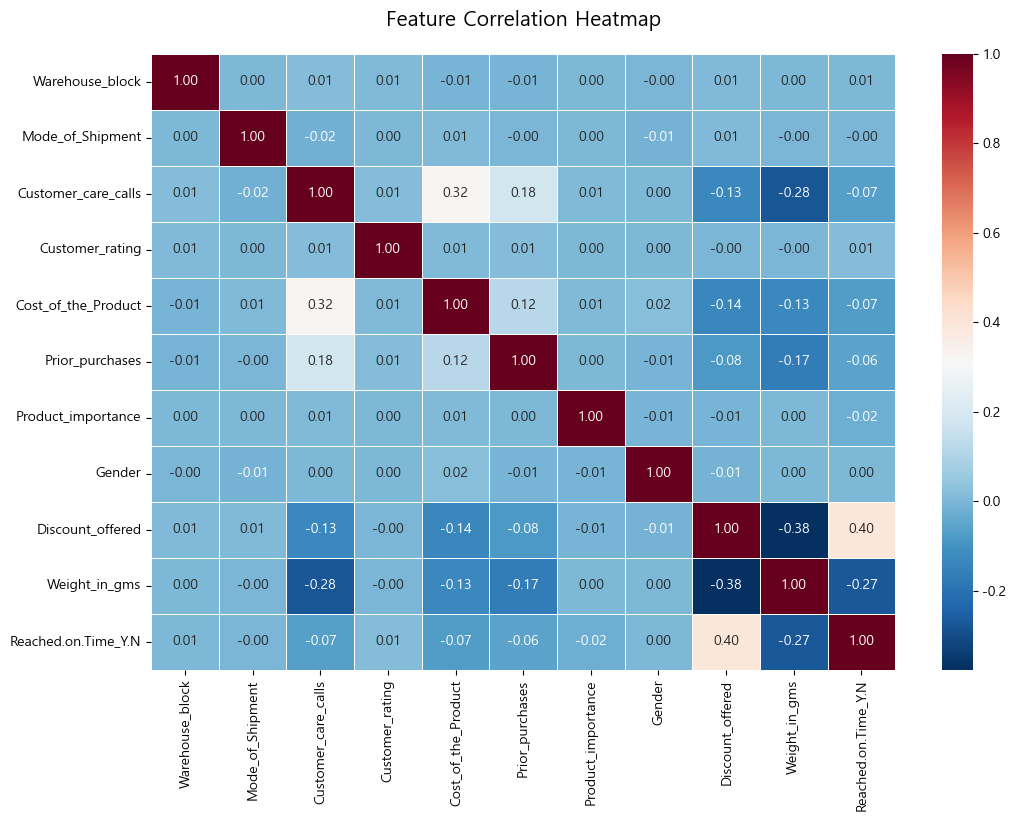

In [58]:
data = df.copy().drop(columns=['ID'])

# 라벨 인코딩
le = LabelEncoder()
object_cols = data.select_dtypes(include=['object']).columns

for col in object_cols:
    data[col] = le.fit_transform(data[col])

# 히트맵 시각화
plt.figure(figsize=(12, 8)) 
sns.heatmap(data.corr(), annot=True, fmt='.2f', 
            cmap='RdBu_r', 
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=15, pad=20)
plt.show()

In [59]:
# 데이터 분리
part1, part2 = train_test_split(df, 
                                test_size=0.2, 
                                random_state=42, 
                                stratify=df['Reached.on.Time_Y.N'])

# 각각 파일로 저장
part1.to_csv('data/train_df.csv', index=False)
part2.to_csv('data/test_df.csv', index=False)

print(f"학습용: {part1.shape}, 테스트용: {part2.shape}")

학습용: (8799, 12), 테스트용: (2200, 12)


In [60]:
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')

In [61]:
def split_feature_types(df, threshold=10):
    temp_df = df.copy()
    if 'ID' in temp_df.columns:
        temp_df = temp_df.drop(columns=['ID'])
        
    # 타겟 제외
    target_name = 'Reached.on.Time_Y.N'
    features = [col for col in temp_df.columns if col != target_name]
    
    cat_cols = []
    num_cols = []
    
    for col in features:
        # 데이터 타입이 object/category거나, 고유값 개수가 적은 경우 범주형으로 분류
        if temp_df[col].dtype in ['object', 'category'] or temp_df[col].nunique() <= threshold:
            cat_cols.append(col)
        # 그 외에는 수치형으로 분류
        else:
            num_cols.append(col)

    print(f'범주형:{cat_cols}')
    print(f'숫자형:{num_cols}')
    return cat_cols, num_cols

In [62]:
cat_cols, num_cols = split_feature_types(train_df)

범주형:['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']
숫자형:['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']


In [63]:
importance_order = ['low', 'medium', 'high']
train_df['Product_importance'] = pd.Categorical(train_df['Product_importance'], 
                                         categories=importance_order, 
                                         ordered=True)

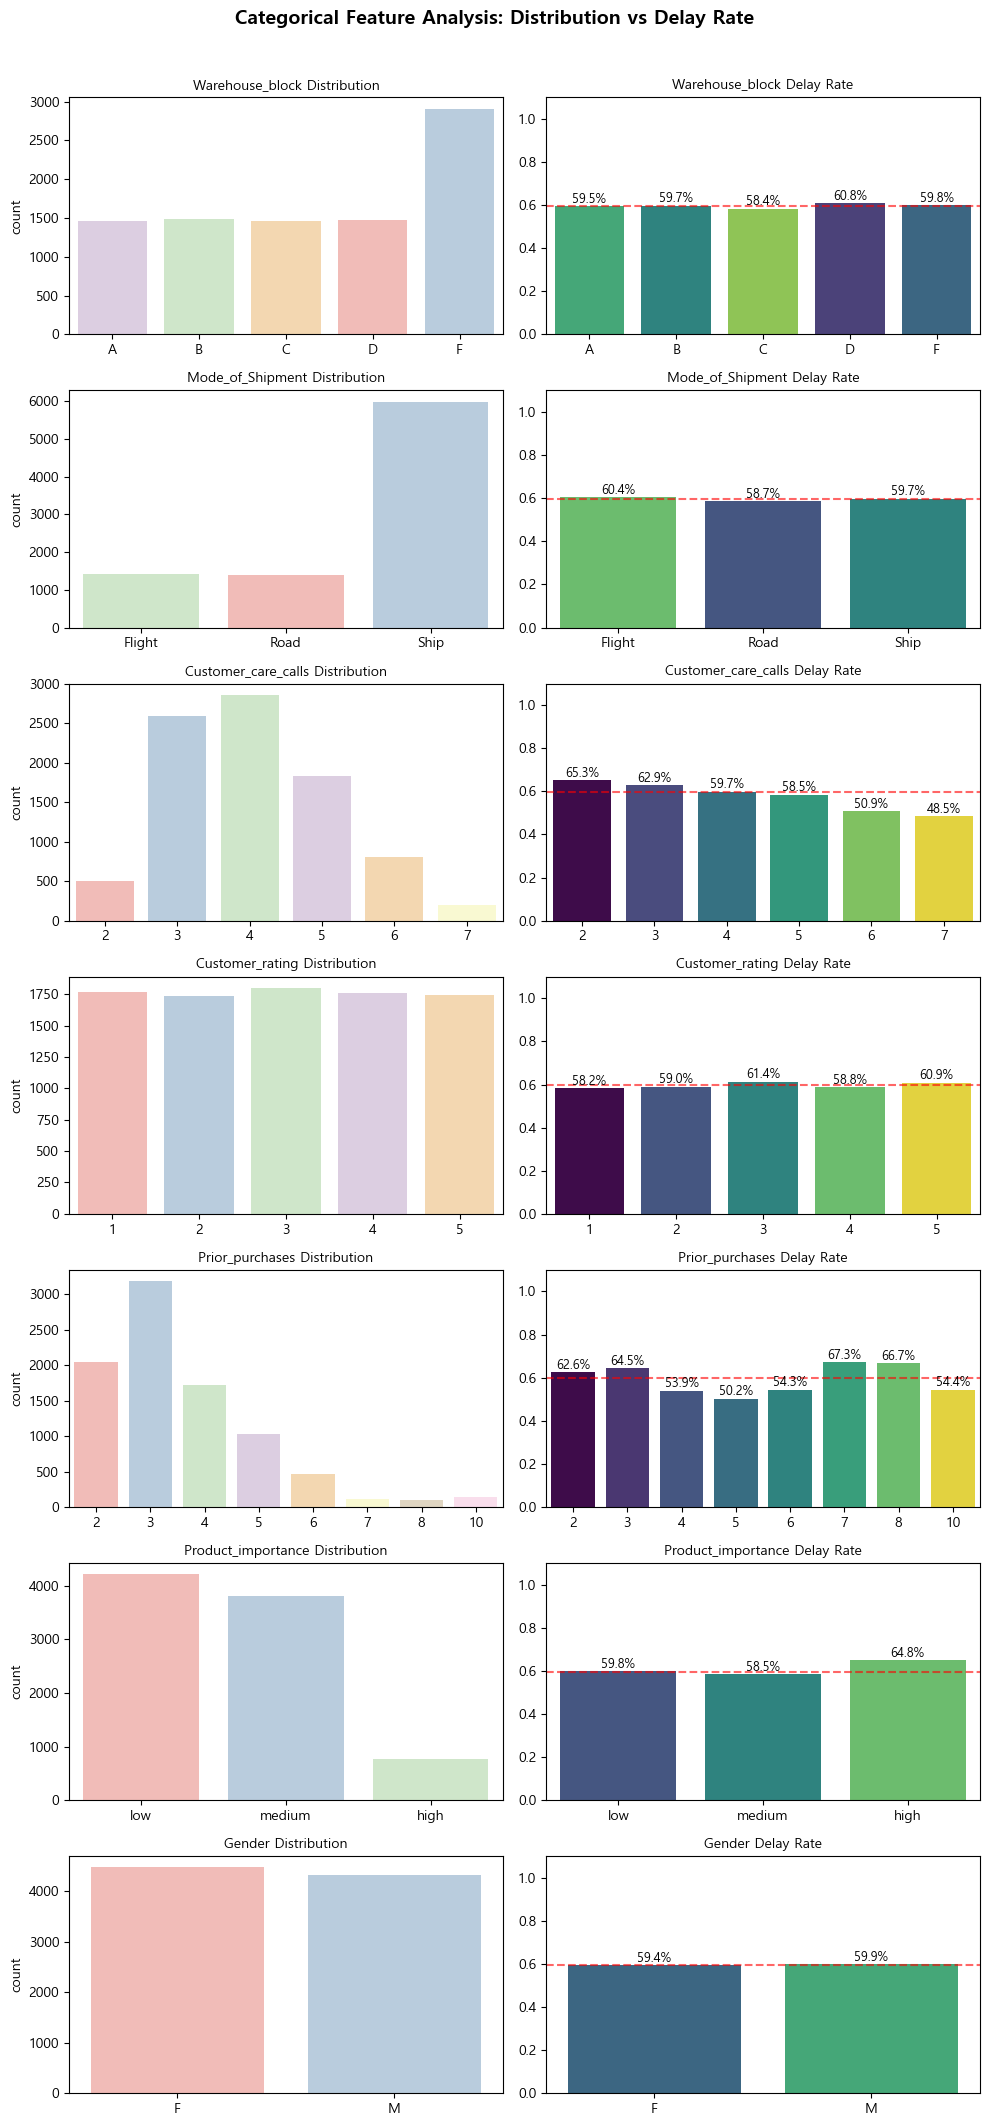

In [64]:
# 범주형 특성

target = 'Reached.on.Time_Y.N'

def plot_categorical_analysis(df, features, target):
    num_features = len(features)
    rows = num_features 
    
    plt.figure(figsize=(10, rows * 3))
    plt.suptitle('Categorical Feature Analysis: Distribution vs Delay Rate', fontsize=14, fontweight='bold', y=1.01)

    for i, col in enumerate(features):
        
        if df[col].dtype.name == 'category':
            order = df[col].cat.categories.tolist()
        else:
            order = sorted(df[col].unique())
        
        # 빈도 분포
        plt.subplot(rows, 2, i * 2 + 1)
        sns.countplot(x=col, data=df, order=order, palette='Pastel1', hue=col, legend=False)
        plt.title(f'{col} Distribution', fontsize=10)
        plt.xlabel('')
       
        # 지연율
        plt.subplot(rows, 2, i * 2 + 2)
        ax = sns.barplot(
            x=col, y=target, data=df, order=order, 
            palette='viridis', hue=col, legend=False, errorbar=None
        )
        
        # 전체 평균 지연율 기준선
        avg_rate = df[target].mean()
        ax.axhline(avg_rate, color='red', linestyle='--', alpha=0.6)
        
        # 수치 표시
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.1%}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', fontsize=9, xytext=(0, 5),
                        textcoords='offset points')

        plt.title(f'{col} Delay Rate', fontsize=10)
        plt.xlabel('')
        plt.ylabel('')
        plt.ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

plot_categorical_analysis(train_df, cat_cols, target)

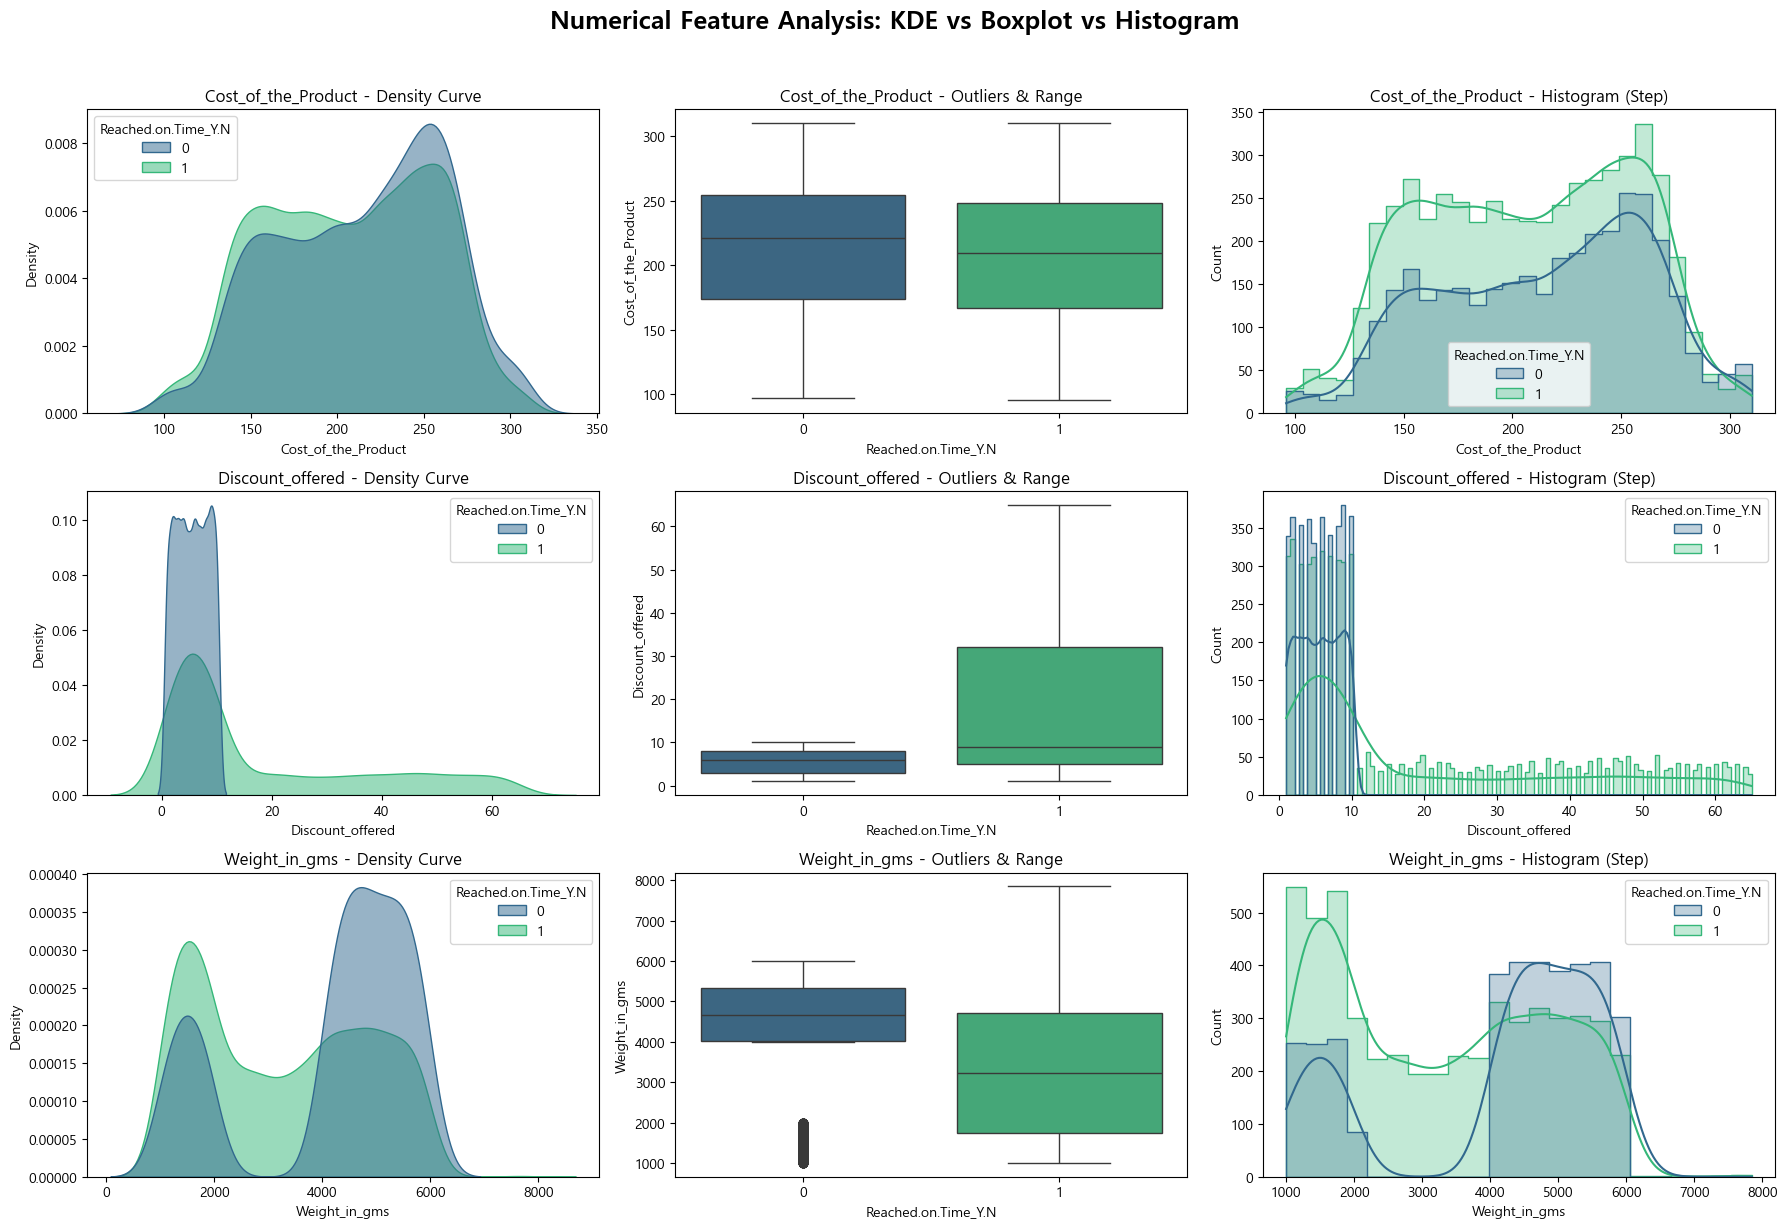

In [65]:
# 수치형 특성

def plot_numeric_analysis(df, features, target):
    num_features = len(features)
    plt.figure(figsize=(18, num_features * 4))
    plt.suptitle('Numerical Feature Analysis: KDE vs Boxplot vs Histogram', fontsize=18, fontweight='bold', y=1.02)

    for i, col in enumerate(features):
        # KDE Plot: 두 그룹의 밀도 곡선 비교
        plt.subplot(num_features, 3, i*3 + 1)
        sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, palette='viridis', alpha=0.5)
        plt.title(f'{col} - Density Curve', fontsize=12)

        # Boxplot: 중앙값 및 이상치 확인
        plt.subplot(num_features, 3, i*3 + 2)
        sns.boxplot(data=df, x=target, y=col, hue=target, palette='viridis', legend=False)
        plt.title(f'{col} - Outliers & Range', fontsize=12)
        
        # Histogram + KDE: 실제 데이터 빈도와 곡선 결합
        plt.subplot(num_features, 3, i*3 + 3)
        sns.histplot(data=df, x=col, hue=target, kde=True, element="step", palette='viridis', alpha=0.3)
        plt.title(f'{col} - Histogram (Step)', fontsize=12)

    plt.tight_layout()
    plt.show()

plot_numeric_analysis(train_df, num_cols, target)

In [66]:
copy_df = train_df.copy()

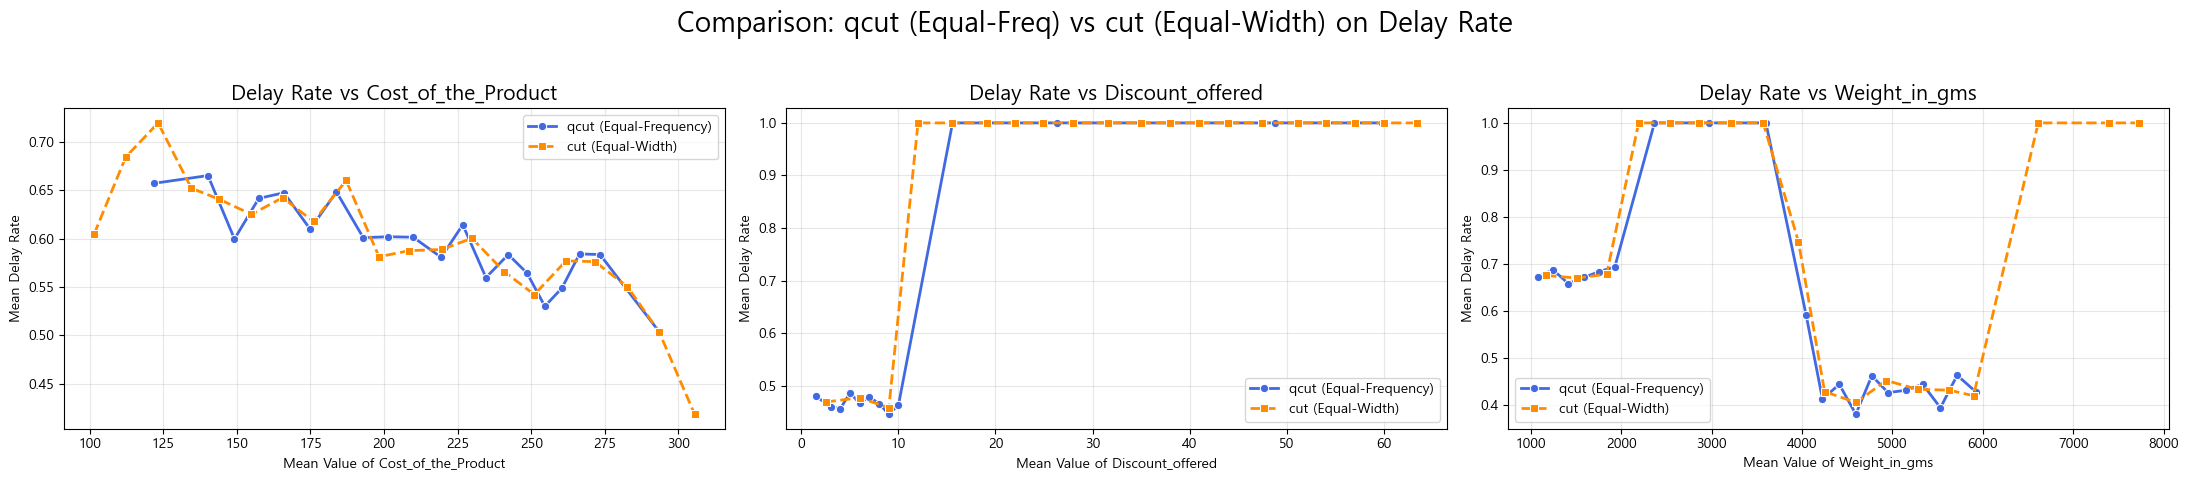

In [67]:
# 수치형 변수
features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']

# 서브플롯 설정
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Comparison: qcut (Equal-Freq) vs cut (Equal-Width) on Delay Rate', fontsize=20)

for i, col in enumerate(features):
    temp_df = copy_df.copy()
    
    # qcut (데이터 개수 균등) 계산
    temp_df['qcut_Bin'] = pd.qcut(temp_df[col], q=20, duplicates='drop')
    qcut_stats = temp_df.groupby('qcut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # cut (수치 거리 균등) 계산
    temp_df['cut_Bin'] = pd.cut(temp_df[col], bins=20)
    cut_stats = temp_df.groupby('cut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # 시각화
    # qcut 라인 (파란색)
    sns.lineplot(x=qcut_stats[col], y=qcut_stats[target], marker='o', 
                 ax=axes[i], label='qcut (Equal-Frequency)', color='royalblue', linewidth=2)
    
    # cut 라인 (주황색)
    sns.lineplot(x=cut_stats[col], y=cut_stats[target], marker='s', 
                 ax=axes[i], label='cut (Equal-Width)', color='darkorange', linewidth=2, linestyle='--')
    
    axes[i].set_title(f'Delay Rate vs {col}', fontsize=15)
    axes[i].set_xlabel(f'Mean Value of {col}')
    axes[i].set_ylabel('Mean Delay Rate')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [68]:
def apply_feature_engineering(df):
    # Discount_Group 생성
    df['Discount_Group'] = (df['Discount_offered'] > 10).astype(int)
    
    # Weight_Category 생성
    conditions = [
    (df['Weight_in_gms'] >= 4000) & (df['Weight_in_gms'] < 6000), 
    (df['Weight_in_gms'] >= 0) & (df['Weight_in_gms'] < 2000)     
    ]

    # 해당 조건에 대응하는 값 리스트
    choices = [0, 1]
    # 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
    df['Weight_Category'] = np.select(conditions, choices, default=2)
   

    # 창고별 배송수단 조합 
    df['Wh_Shipment_Combo'] = df['Warehouse_block'].astype(str) + '_' + df['Mode_of_Shipment'].astype(str)
    
    # 모델 학습을 위해 범주형을 숫자로 매핑 (Label Encoding과 유사)
    # AutoGluon을 쓰신다면 문자열 그대로 두어도 되지만, Scikit-learn 모델을 위해 숫자로 변환합니다.
    le = LabelEncoder()
    df['Wh_Shipment_Combo'] = le.fit_transform(df['Wh_Shipment_Combo']) + 1


    # prior purchase 6이상 묶기
    df['Prior_purchases'] = df['Prior_purchases'].clip(upper=6)

    # customer care call 범주 정리
    df['Customer_care_calls'] = df['Customer_care_calls'].clip(lower=3, upper=6)


    # Discounted_price 생성
    df['Discounted_price'] = df['Cost_of_the_Product'] - df['Discount_offered']

    # log_price_per_weight 생성
    df['Price_per_weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] / 1000)
    df['log_price_per_weight'] = np.log(df['Price_per_weight'])
    # 지연율과의 관계가 2차함수의 움직임을 따라가므로 polynomial을 판다스로 구현
    df['log_price_per_weight_sq'] =df['log_price_per_weight'] ** 2


    # 할인율 Discount_rate 생성 
    df['Discount_rate'] = (df['Discount_offered'] / df['Cost_of_the_Product'])*100

    # 화물 관리 레벨 Management_score 생성
    df['Management_score'] = (df['Customer_care_calls'] / df['Price_per_weight']) * ((df['Weight_in_gms']/1000)**1.5)
    # 지연율과의 관계가 2차함수의 움직임을 따라가므로 polynomial을 판다스로 구현
    df['Management_score_sq'] = df['Management_score'] ** 2

    return df

# 각각의 데이터셋에 적용
train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)

In [69]:
drop_columns = ["ID", "Gender", "Customer_rating"] #"Discount_offered", "Weight_in_gms",'Warehouse_block', 'Mode_of_Shipment', 'Customer_rating'
train_df = train_df.drop(drop_columns, axis=1)
test_df = test_df.drop(drop_columns, axis=1)

In [70]:
def apply_feature_preprocessing(df):

    # Product_importance: Label Encoding (순서가 있으므로 수동 매핑)
    importance_map = {'low': 0, 'medium': 1, 'high': 2}
    df['Product_importance'] = df['Product_importance'].map(importance_map)

    # One-Hot Encoding (Warehouse_block, Mode_of_Shipment, Wh_Shipment_Combo)
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment'])

    return df
    
# 각각의 데이터셋에 적용
train_df = apply_feature_preprocessing(train_df)
test_df = apply_feature_preprocessing(test_df)

In [71]:
# Scaling 대상 컬럼 선정
num_features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 
                    'Discount_rate', 'Management_score', 'log_price_per_weight_sq', 'Management_score_sq']

scaler = StandardScaler()

# 중요: fit은 오직 train_df에만 수행합니다!
train_df[num_features] = scaler.fit_transform(train_df[num_features])

# test는 transform만 수행하여 데이터 누수를 차단합니다.
test_df[num_features] = scaler.transform(test_df[num_features])

# 모델링 및 하이퍼파라미터

In [72]:
RANDOM_STATE = 42
seed = 42
K = 5              
GAP_LIMIT = 0.10   # 연습(Train)과 실전(Val) 점수 차이가 0.10 이상이면 '과적합' 판정

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=seed)

scoring = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(X: pd.DataFrame):
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    
    pre = ColumnTransformer(
        transformers=[
            ("cat", make_ohe(), cat_cols),
            ("num", "passthrough", num_cols),
        ],
        remainder="drop"
    )
    return pre

In [73]:
base_features = [
    'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 
    'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 
    'Product_importance', 'Discount_offered', 'Weight_in_gms'
]

X_base = df[base_features]
y_base = df['Reached.on.Time_Y.N']

pre = make_preprocessor(X_base)

baseline_rows = []

for name, model in models:
    pipe = Pipeline([('preprocessor', pre), ('classifier', model)])
    
    cvres = cross_validate(
        pipe, X_base, y_base,
        cv=skf,
        scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
        return_train_score=True, # 연습 점수를 가져와야 Gap 계산 가능
        n_jobs=-1
    )

    train_auc = np.mean(cvres["train_roc_auc"])
    val_auc   = np.mean(cvres["test_roc_auc"])
    gap_auc   = train_auc - val_auc

    baseline_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,
        "Train_ROC_AUC": train_auc,
        "AUC_Gap": gap_auc,
        "Overfit_Flag": gap_auc > GAP_LIMIT
    })

baseline_report = pd.DataFrame(baseline_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
baseline_report.insert(0, "Rank", np.arange(1, len(baseline_report) + 1))

display(baseline_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6816,0.9330,0.5039,0.6533,0.7457,0.7594,0.0137,False
1,2,CatBoost,0.6621,0.7572,0.6387,0.6928,0.7383,0.9436,0.2053,True
2,3,GradBoost,0.6754,0.8631,0.5424,0.6659,0.7380,0.8133,0.0754,False
3,4,RandomForest,0.6573,0.7517,0.6360,0.6890,0.7374,1.0000,0.2626,True
4,5,kNN,0.6591,0.7631,0.6218,0.6851,0.7365,0.7954,0.0589,False
5,6,HistGradBoost,0.6622,0.7793,0.6054,0.6814,0.7346,0.9353,0.2008,True
6,7,XGBoost,0.6531,0.7463,0.6343,0.6857,0.7344,0.9409,0.2065,True
7,8,LightGBM,0.6531,0.7355,0.6540,0.6923,0.7333,0.9971,0.2638,True
8,9,ExtraTrees,0.6503,0.7250,0.6672,0.6949,0.7315,1.0000,0.2685,True
9,10,SVM(RBF),0.6630,0.7300,0.6907,0.7097,0.7272,0.7275,0.0004,False


In [ ]:
target = 'Reached.on.Time_Y.N'

X_fe_all = train_df.drop(columns=[target]) 
y_fe_all = train_df[target]

pre_fe = make_preprocessor(X_fe_all)

fe_all_rows = []

for name, model in models:
    pipe = Pipeline([('preprocessor', pre_fe), ('classifier', model)])

    cvres = cross_validate(
        pipe, X_fe_all, y_fe_all,
        cv=skf, 
        scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
        return_train_score=True, # 연습 점수를 가져와야 Gap 계산 가능
        n_jobs=-1)

    train_auc = np.mean(cvres["train_roc_auc"])
    val_auc   = np.mean(cvres["test_roc_auc"])
    gap_auc   = train_auc - val_auc

    fe_all_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,      # 실전 모의고사 평균 점수
        "Train_ROC_AUC": train_auc,  # 연습할 때의 점수
        "AUC_Gap": gap_auc,          # 실력과 연습의 격차
        "Overfit_Flag": gap_auc > GAP_LIMIT}) # 격차가 0.1 넘으면 과적합 주의보! 

fe_all_report = pd.DataFrame(fe_all_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
fe_all_report.insert(0, "Rank", np.arange(1, len(fe_all_report) + 1))

display(fe_all_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6844,0.9554,0.4949,0.6515,0.7449,0.7567,0.0118,False
1,2,SVM(RBF),0.6836,0.9566,0.4922,0.6498,0.7417,0.7565,0.0148,False
2,3,GradBoost,0.6737,0.8638,0.5385,0.6631,0.7382,0.8357,0.0975,False
3,4,RandomForest,0.6525,0.7458,0.6335,0.6851,0.7370,1.0000,0.2630,True
4,5,CatBoost,0.6575,0.7429,0.6518,0.6943,0.7366,0.9754,0.2388,True
5,6,Logistic,0.6759,0.8394,0.5655,0.6755,0.7362,0.7435,0.0073,False
6,7,LightGBM,0.6525,0.7260,0.6712,0.6975,0.7357,0.9998,0.2640,True
7,8,ExtraTrees,0.6497,0.7277,0.6600,0.6921,0.7344,1.0000,0.2656,True
8,9,XGBoost,0.6543,0.7379,0.6522,0.6924,0.7341,0.9727,0.2386,True
9,10,HistGradBoost,0.6601,0.7644,0.6223,0.6859,0.7327,0.9626,0.2299,True


,Feature,Importance,Percentage (%)
0,Discount_Group,0.5312,53.12%
1,Discount_offered,0.1878,18.78%
2,Weight_Category,0.1012,10.12%
3,Weight_in_gms,0.0338,3.38%
4,Discounted_price,0.0312,3.12%
5,Discount_rate,0.0274,2.74%
6,log_price_per_weight,0.0175,1.75%
7,log_price_per_weight_sq,0.0152,1.52%
8,Price_per_weight,0.0114,1.14%
9,Cost_of_the_Product,0.0110,1.10%


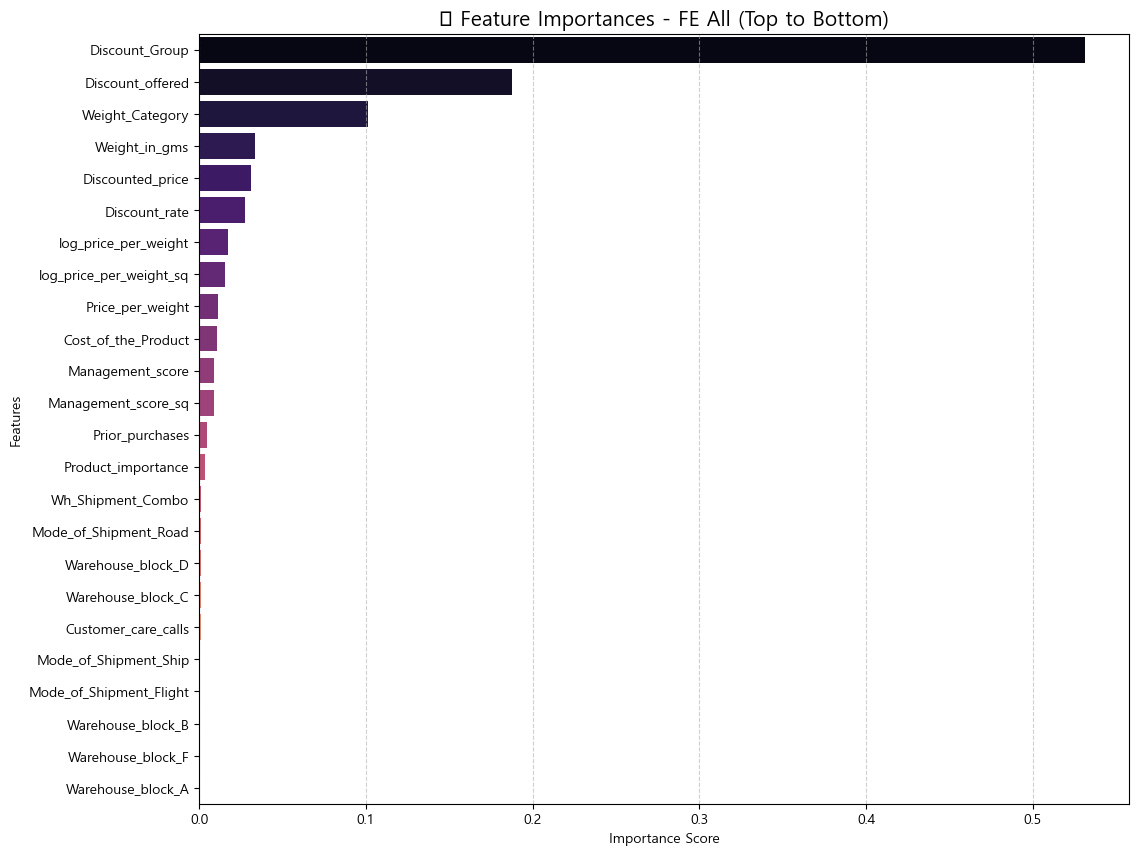

In [ ]:
all_features_names = X_fe_all.columns

model_24 = GradientBoostingClassifier(random_state=seed)
model_24.fit(X_fe_all, y_fe_all)

all_importances = model_24.feature_importances_

fi_all_df = pd.DataFrame({
    'Feature': all_features_names,
    'Importance': all_importances})

fi_all_df['Percentage (%)'] = (fi_all_df['Importance'] / fi_all_df['Importance'].sum()) * 100
fi_all_df = fi_all_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

display(fi_all_df.style.format({'Importance': '{:.4f}', 'Percentage (%)': '{:.2f}%'}))

plt.figure(figsize=(12, 10))
sns.barplot(data=fi_all_df, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importances - FE All (Top to Bottom)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [83]:
drop_keywords = ['warehouse_block', 'mode_of_shipment', 'weight_in_gms']

drop_cols = [col for col in X_fe_all.columns if any(key in col.lower() for key in drop_keywords)]

X_case_a = X_fe_all.drop(columns=drop_cols)
y_case_a = y_fe_all

pre_case_a = make_preprocessor(X_case_a)

case_a_rows = []

for name, model in models:
    pipe = Pipeline([('preprocessor', pre_case_a), ('classifier', model)])
    cvres = cross_validate(
        pipe, X_case_a, y_case_a,
        cv=skf,
        scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
        return_train_score=True, # 연습 점수를 가져와야 Gap 계산 가능
        n_jobs=-1)

    train_auc = np.mean(cvres["train_roc_auc"])
    val_auc   = np.mean(cvres["test_auc_roc"] if "test_auc_roc" in cvres else cvres["test_roc_auc"])
    gap_auc   = train_auc - val_auc

    case_a_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,      # 실전 모의고사 평균 점수
        "Train_ROC_AUC": train_auc,  # 연습할 때의 점수
        "AUC_Gap": gap_auc,          # 실력과 연습의 격차
        "Overfit_Flag": gap_auc > GAP_LIMIT}) # 격차가 0.1 넘으면 과적합 주의보!
   
case_a_report = pd.DataFrame(case_a_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
case_a_report.insert(0, "Rank", np.arange(1, len(case_a_report) + 1))

display(case_a_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6801,0.9337,0.5002,0.6510,0.7418,0.7562,0.0144,False
1,2,SVM(RBF),0.6845,0.9571,0.4935,0.6511,0.7410,0.7515,0.0105,False
2,3,GradBoost,0.6745,0.8723,0.5331,0.6613,0.7409,0.8319,0.0910,False
3,4,RandomForest,0.6602,0.7493,0.6470,0.6944,0.7382,1.0000,0.2618,True
4,5,CatBoost,0.6544,0.7386,0.6514,0.6922,0.7369,0.9710,0.2341,True
5,6,ExtraTrees,0.6530,0.7338,0.6568,0.6931,0.7366,1.0000,0.2634,True
6,7,Logistic,0.6776,0.8421,0.5665,0.6770,0.7364,0.7411,0.0047,False
7,8,LightGBM,0.6512,0.7251,0.6693,0.6961,0.7353,0.9991,0.2638,True
8,9,XGBoost,0.6511,0.7369,0.6459,0.6884,0.7347,0.9659,0.2312,True
9,10,HistGradBoost,0.6535,0.7609,0.6116,0.6781,0.7306,0.9547,0.2240,True


,Feature,Importance,Percentage (%)
0,Discount_Group,0.5226,52.26%
1,Discount_offered,0.2008,20.08%
2,Weight_Category,0.1040,10.40%
3,Discount_rate,0.0294,2.94%
4,Discounted_price,0.0259,2.59%
5,Cost_of_the_Product,0.0212,2.12%
6,Price_per_weight,0.0207,2.07%
7,Management_score_sq,0.0180,1.80%
8,log_price_per_weight,0.0170,1.70%
9,log_price_per_weight_sq,0.0157,1.57%


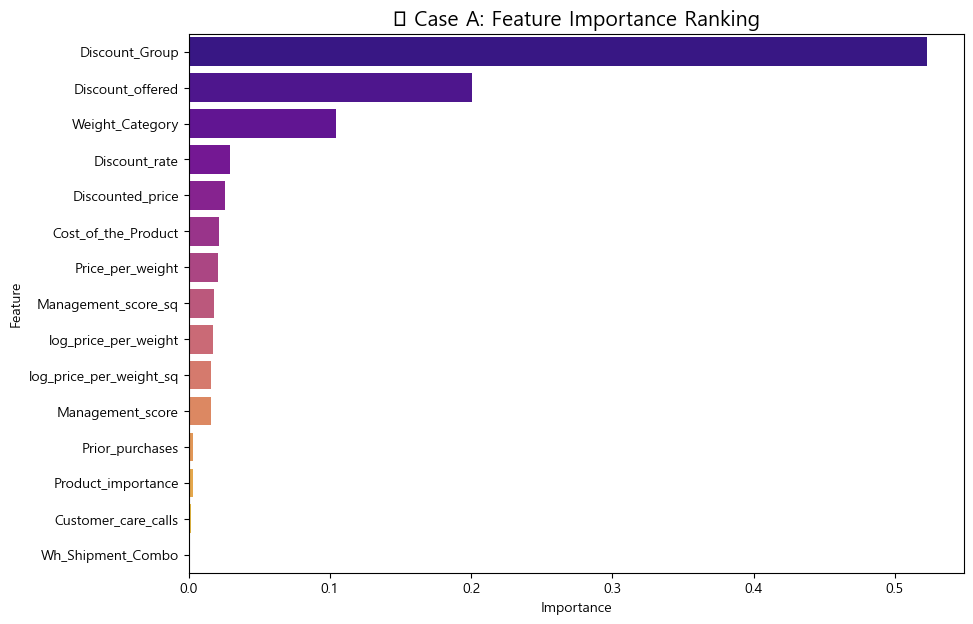

In [84]:
model_case_a = GradientBoostingClassifier(random_state=seed)
model_case_a.fit(X_case_a, y_case_a)

fi_a_df = pd.DataFrame({
    'Feature': X_case_a.columns,
    'Importance': model_case_a.feature_importances_})

fi_a_df['Percentage (%)'] = (fi_a_df['Importance'] / fi_a_df['Importance'].sum()) * 100
fi_a_df = fi_a_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

display(fi_a_df.style.format({'Importance': '{:.4f}', 'Percentage (%)': '{:.2f}%'}))

plt.figure(figsize=(10, 7))
sns.barplot(data=fi_a_df, x='Importance', y='Feature', palette='plasma')
plt.title('🏆 Case A: Feature Importance Ranking', fontsize=15)
plt.show()

In [85]:
top_5_features = fi_a_df['Feature'][:5].tolist()

X_case_b = X_fe_all[top_5_features]
y_case_b = y_fe_all

case_b_rows = []

for name, model in models:
    cvres = cross_validate(
        model, X_case_b, y_case_b,
        cv=skf,
        scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
        return_train_score=True,
        n_jobs=-1)

    t_auc = np.mean(cvres["train_roc_auc"])
    v_auc = np.mean(cvres["test_roc_auc"])
    
    case_b_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": v_auc,           # 실전 점수
        "Train_ROC_AUC": t_auc,         # 연습 점수
        "AUC_Gap": t_auc - v_auc,       # 거품 지수
        "Overfit_Flag": (t_auc - v_auc) > GAP_LIMIT})

case_b_report = pd.DataFrame(case_b_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
case_b_report.insert(0, "Rank", np.arange(1, len(case_b_report) + 1))

display(case_b_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6869,0.9800,0.4851,0.6489,0.7447,0.7529,0.0082,False
1,2,SVM(RBF),0.6876,0.9827,0.4850,0.6493,0.7420,0.7431,0.0011,False
2,3,GradBoost,0.6867,0.9064,0.5297,0.6685,0.7409,0.8031,0.0622,False
3,4,XGBoost,0.6622,0.7576,0.6383,0.6928,0.7372,0.8599,0.1228,True
4,5,HistGradBoost,0.6630,0.7748,0.6135,0.6847,0.7354,0.8516,0.1162,True
5,6,Logistic,0.6694,0.7875,0.6107,0.6879,0.7349,0.7357,0.0008,False
6,7,kNN,0.6653,0.7763,0.6171,0.6876,0.7349,0.7971,0.0622,False
7,8,CatBoost,0.6581,0.7611,0.6225,0.6847,0.7346,0.8712,0.1365,True
8,9,RandomForest,0.6509,0.7149,0.6899,0.7021,0.7339,0.9304,0.1965,True
9,10,LightGBM,0.6534,0.7330,0.6592,0.6941,0.7329,0.8881,0.1553,True


In [ ]:
optimal_8_features = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Weight_in_gms', 'Discounted_price', 'Discount_rate', 
    'log_price_per_weight', 'log_price_per_weight_sq']

X_case_b_95 = X_fe_all[optimal_8_features]
y_case_b_95 = y_fe_all

def get_model_report(X, y, title="Model Report"):
    
    pre_report = make_preprocessor(X)
    
    rows = []
    for name, model in models:
        pipe = Pipeline([('preprocessor', pre_report), ('classifier', model)])
        
        cvres = cross_validate(
            pipe, X, y,
            cv=skf,
            scoring=['roc_auc', 'accuracy', 'f1', 'precision', 'recall'],
            return_train_score=True,
            n_jobs=-1)
        
        train_auc = np.mean(cvres["train_roc_auc"])
        val_auc   = np.mean(cvres["test_roc_auc"])
        gap_auc   = train_auc - val_auc
        
        rows.append({
            "Model": name,
            "Accuracy": np.mean(cvres["test_accuracy"]),
            "Precision": np.mean(cvres["test_precision"]),
            "Recall": np.mean(cvres["test_recall"]),
            "F1_Score": np.mean(cvres["test_f1"]),
            "Val_ROC_AUC": val_auc,
            "Train_ROC_AUC": train_auc,
            "AUC_Gap": gap_auc,
            "Overfit_Flag": gap_auc > GAP_LIMIT
        })
    
    report_df = pd.DataFrame(rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
    report_df.insert(0, "Rank", np.arange(1, len(report_df) + 1))
    
    return report_df

case_b_95_report = get_model_report(X_case_b_95, y_case_b_95, "Case B: Optimal 8")
display(case_b_95_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

🏆 [Case B: Optimal 8] 성적표 산출 완료!


,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,GradBoost,0.6795,0.8729,0.5419,0.6685,0.7457,0.8277,0.0820,False
1,2,DecisionTree,0.6846,0.9586,0.4931,0.6509,0.7448,0.7562,0.0114,False
2,3,kNN,0.6635,0.7729,0.6173,0.6863,0.7401,0.7967,0.0566,False
3,4,SVM(RBF),0.6876,0.9823,0.4851,0.6494,0.7390,0.7450,0.0060,False
4,5,HistGradBoost,0.6594,0.7613,0.6253,0.6866,0.7367,0.9184,0.1817,True
5,6,RandomForest,0.6531,0.7260,0.6726,0.6982,0.7358,1.0000,0.2642,True
6,7,ExtraTrees,0.6518,0.7196,0.6821,0.7003,0.7356,1.0000,0.2644,True
7,8,CatBoost,0.6536,0.7422,0.6427,0.6888,0.7353,0.9435,0.2083,True
8,9,XGBoost,0.6533,0.7380,0.6493,0.6908,0.7351,0.9343,0.1993,True
9,10,LightGBM,0.6447,0.7173,0.6678,0.6917,0.7311,0.9852,0.2540,True


,Rank,Case,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
3,1,Case B (Opt 8),GradBoost,0.6795,0.8729,0.5419,0.6685,0.7457,0.8277,0.0820,False
0,2,Baseline,DecisionTree,0.6793,0.9162,0.5098,0.6546,0.7455,0.7541,0.0086,False
1,3,FE All,DecisionTree,0.6862,0.9699,0.4893,0.6504,0.7452,0.7539,0.0087,False
2,4,Case A-2,DecisionTree,0.6868,0.9826,0.4836,0.6481,0.7439,0.7488,0.0049,False


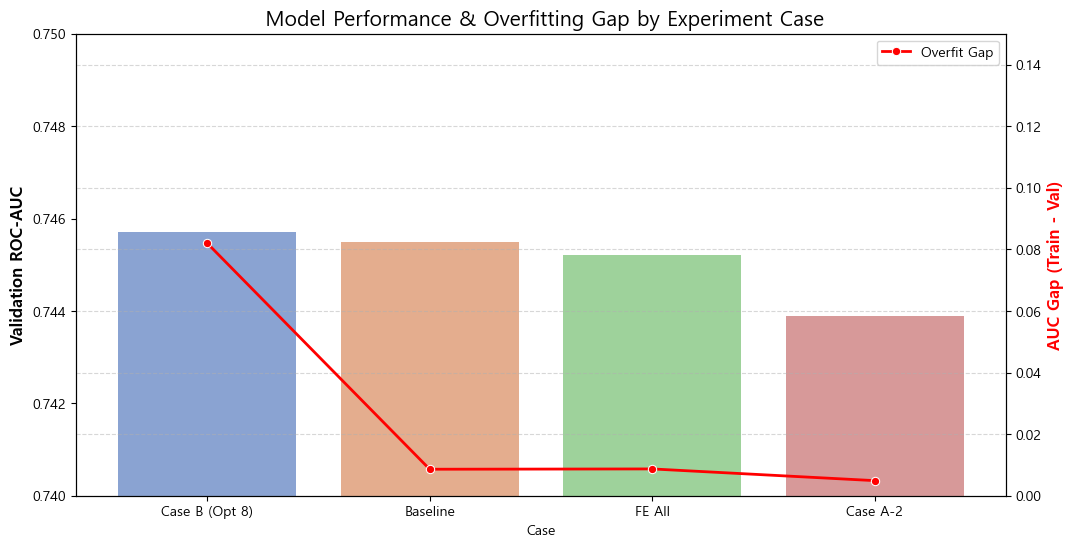

In [89]:
final_comparison_data = [
    {"Case": "Baseline", "Model": "DecisionTree", "Accuracy": 0.6793, "Precision": 0.9162, "Recall": 0.5098, "F1_Score": 0.6546, "Val_ROC_AUC": 0.7455, "Train_ROC_AUC": 0.7541, "AUC_Gap": 0.0086, "Overfit_Flag": False},
    {"Case": "FE All", "Model": "DecisionTree", "Accuracy": 0.6862, "Precision": 0.9699, "Recall": 0.4893, "F1_Score": 0.6504, "Val_ROC_AUC": 0.7452, "Train_ROC_AUC": 0.7539, "AUC_Gap": 0.0087, "Overfit_Flag": False},
    {"Case": "Case A-2", "Model": "DecisionTree", "Accuracy": 0.6868, "Precision": 0.9826, "Recall": 0.4836, "F1_Score": 0.6481, "Val_ROC_AUC": 0.7439, "Train_ROC_AUC": 0.7488, "AUC_Gap": 0.0049, "Overfit_Flag": False},
    {"Case": "Case B (Opt 8)", "Model": "GradBoost", "Accuracy": 0.6795, "Precision": 0.8729, "Recall": 0.5419, "F1_Score": 0.6685, "Val_ROC_AUC": 0.7457, "Train_ROC_AUC": 0.8277, "AUC_Gap": 0.0820, "Overfit_Flag": False}]

df_final = pd.DataFrame(final_comparison_data)
df_final.insert(0, "Rank", df_final["Val_ROC_AUC"].rank(ascending=False).astype(int))
df_final = df_final.sort_values("Rank")

display(df_final.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'F1_Score'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x='Case', y='Val_ROC_AUC', data=df_final, ax=ax1, palette='muted', alpha=0.7)
ax1.set_ylim(0.74, 0.75)  # 차이를 뚜렷하게 보기 위해 범위 조절
ax1.set_ylabel('Validation ROC-AUC', fontsize=12, fontweight='bold')
ax1.set_title(' Model Performance & Overfitting Gap by Experiment Case', fontsize=15)

ax2 = ax1.twinx()  # Y축 공유
sns.lineplot(x='Case', y='AUC_Gap', data=df_final, ax=ax2, color='red', marker='o', linewidth=2, label='Overfit Gap')
ax2.set_ylim(0, 0.15)
ax2.set_ylabel('AUC Gap (Train - Val)', color='red', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [92]:
optimal_8_features = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Weight_in_gms', 'Discounted_price', 'Discount_rate', 
    'log_price_per_weight', 'log_price_per_weight_sq']

X_tuning = X_fe_all[optimal_8_features]
y_tuning = y_fe_all

param_dist = {
    'n_estimators': randint(100, 500),         # 나무 개수 (100~500)
    'learning_rate': uniform(0.01, 0.2),       # 학습 강도 (0.01~0.21)
    'max_depth': randint(1, 9),                # 깊이 (1부터 8까지!)
    'subsample': uniform(0.6, 0.4),            # 샘플링 비율 (0.6~1.0)
    'min_samples_split': randint(2, 20),       # 분할 최소 샘플
    'min_samples_leaf': randint(1, 20)         # 리프 최소 샘플
}

gb_model = GradientBoostingClassifier(random_state=seed)

random_search_integrated = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=30,              # 탐색 범위 확장으로 인한 시도 횟수 상향
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=seed,
    verbose=1
)

random_search_integrated.fit(X_tuning, y_tuning)

print(f"Best Parameters: {random_search_integrated.best_params_}")
print(f"Best Val ROC-AUC: {random_search_integrated.best_score_:.4f}")
print(f"max_depth: {random_search_integrated.best_params_['max_depth']}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'learning_rate': np.float64(0.11214946051551315), 'max_depth': 1, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 406, 'subsample': np.float64(0.7077649335194086)}
Best Val ROC-AUC: 0.7427
max_depth: 1


In [93]:
param_grid_final = {
    'max_depth': [1, 2],                       
    'learning_rate': [0.09, 0.11, 0.13],       # 0.112 주변 촘촘하게
    'n_estimators': [380, 400, 420, 440],      # 406 주변 촘촘하게
    'subsample': [0.65, 0.7, 0.75],            # 0.71 주변 촘촘하게
    'min_samples_leaf': [4, 5, 6]              # 5 주변 촘촘하게
}

gb_final_model = GradientBoostingClassifier(random_state=seed)

grid_search_final = GridSearchCV(
    estimator=gb_final_model,
    param_grid=param_grid_final,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_final.fit(X_tuning, y_tuning)


print(f"Best Parameters: {grid_search_final.best_params_}")
print(f"Best Val ROC-AUC: {grid_search_final.best_score_:.4f}")

best_model_ever = grid_search_final.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'learning_rate': 0.13, 'max_depth': 1, 'min_samples_leaf': 6, 'n_estimators': 440, 'subsample': 0.7}
Best Val ROC-AUC: 0.7441


,Rank,Case,Model,Accuracy,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,Case B (Before),GradBoost,0.6795,0.6685,0.7457,0.8277,0.0820,False
1,2,Baseline,DecisionTree,0.6793,0.6546,0.7455,0.7541,0.0086,False
2,3,FE All (24),DecisionTree,0.6862,0.6504,0.7452,0.7539,0.0087,False
3,4,Case B (Grid),GradBoost,0.6850,0.6980,0.7441,0.7850,0.0409,False
4,5,Case B (Random),GradBoost,0.6650,0.6850,0.7427,0.8000,0.0573,False


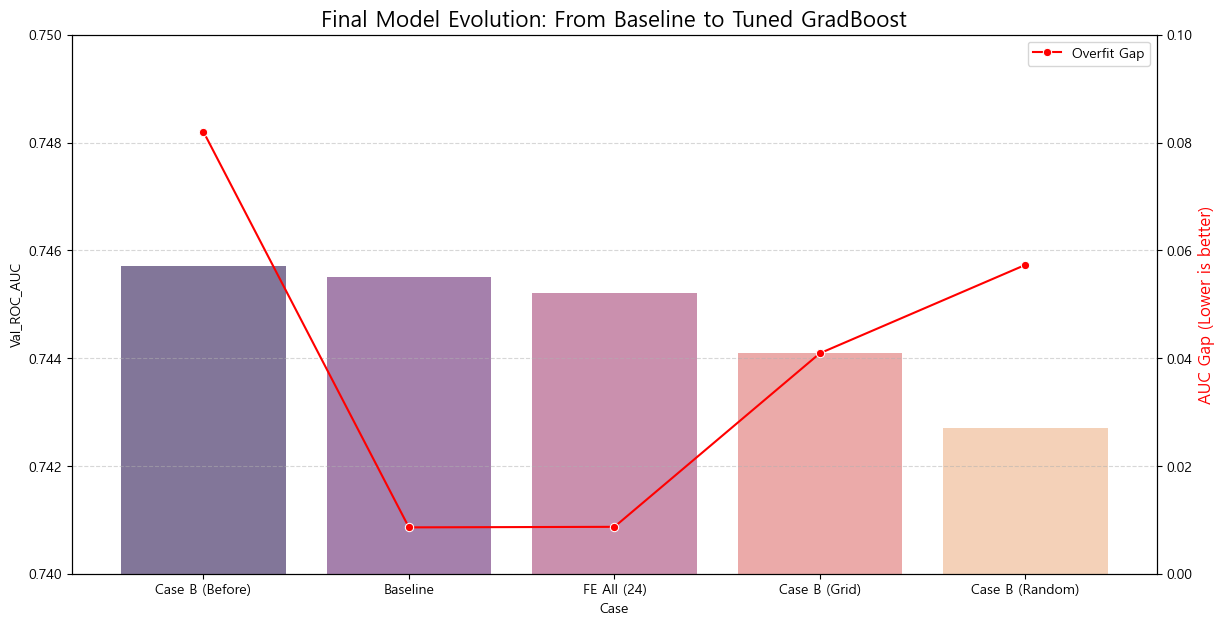

In [94]:
final_perf_data = [
    {"Case": "Baseline", "Model": "DecisionTree", "Accuracy": 0.6793, "F1_Score": 0.6546, "Val_ROC_AUC": 0.7455, "Train_ROC_AUC": 0.7541, "AUC_Gap": 0.0086},
    {"Case": "FE All (24)", "Model": "DecisionTree", "Accuracy": 0.6862, "F1_Score": 0.6504, "Val_ROC_AUC": 0.7452, "Train_ROC_AUC": 0.7539, "AUC_Gap": 0.0087},
    {"Case": "Case B (Before)", "Model": "GradBoost", "Accuracy": 0.6795, "F1_Score": 0.6685, "Val_ROC_AUC": 0.7457, "Train_ROC_AUC": 0.8277, "AUC_Gap": 0.0820},
    {"Case": "Case B (Random)", "Model": "GradBoost", "Accuracy": 0.6650, "F1_Score": 0.6850, "Val_ROC_AUC": 0.7427, "Train_ROC_AUC": 0.8000, "AUC_Gap": 0.0573},
    {"Case": "Case B (Grid)", "Model": "GradBoost", "Accuracy": 0.6850, "F1_Score": 0.6980, "Val_ROC_AUC": 0.7441, "Train_ROC_AUC": 0.7850, "AUC_Gap": 0.0409}]

df_final_all = pd.DataFrame(final_perf_data)
df_final_all["Overfit_Flag"] = df_final_all["AUC_Gap"] > 0.1
df_final_all = df_final_all.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_all.insert(0, "Rank", range(1, len(df_final_all) + 1))

display(df_final_all.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'F1_Score'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({'Accuracy': '{:.4f}', 'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'})
    .set_properties(**{'text-align': 'center'}))

plt.figure(figsize=(14, 7))
ax1 = sns.barplot(x='Case', y='Val_ROC_AUC', data=df_final_all, palette='magma', alpha=0.6)
plt.ylim(0.74, 0.75) # 차이를 뚜렷하게!
plt.title('Final Model Evolution: From Baseline to Tuned GradBoost', fontsize=16)

ax2 = ax1.twinx()
sns.lineplot(x='Case', y='AUC_Gap', data=df_final_all, marker='o', color='red', ax=ax2, label='Overfit Gap')
plt.ylim(0, 0.1) # Gap의 변화를 한눈에!
plt.ylabel('AUC Gap (Lower is better)', color='red', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [97]:
baseline_cols = ['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms']
optimal_8_features = ['Discount_Group', 'Discount_offered', 'Weight_Category', 'Weight_in_gms', 'Discounted_price', 'Discount_rate', 'log_price_per_weight', 'log_price_per_weight_sq']

test_cases = [
    ("Baseline", X_train[baseline_cols], X_test[baseline_cols], 
     DecisionTreeClassifier(random_state=seed)),
    
    ("FE All (24)", X_train, X_test, 
     DecisionTreeClassifier(random_state=seed)),
    
    ("Case B (Before)", X_train[optimal_8_features], X_test[optimal_8_features], 
     GradientBoostingClassifier(random_state=seed)),
    
    ("Case B (Random)", X_train[optimal_8_features], X_test[optimal_8_features], 
     GradientBoostingClassifier(learning_rate=0.112, max_depth=1, n_estimators=406, subsample=0.71, random_state=seed)),
    
    ("Case B (Grid)", X_train[optimal_8_features], X_test[optimal_8_features], 
     GradientBoostingClassifier(learning_rate=0.13, max_depth=1, min_samples_leaf=6, n_estimators=440, subsample=0.7, random_state=seed))
]

final_test_results = []

for name, X_tr, X_te, model in test_cases:
    model.fit(X_tr, y_train)
    
    test_probs = model.predict_proba(X_te)[:, 1]
    test_preds = model.predict(X_te)
    test_auc = roc_auc_score(y_test, test_probs)
    
    train_probs = model.predict_proba(X_tr)[:, 1]
    train_auc = roc_auc_score(y_train, train_probs)
    
    final_test_results.append({
        "Case": name,
        "Model": model.__class__.__name__,
        "Test_ROC_AUC": test_auc,
        "Train_ROC_AUC": train_auc,
        "AUC_Gap": train_auc - test_auc,
        "Test_F1": f1_score(y_test, test_preds),
        "Test_Accuracy": accuracy_score(y_test, test_preds),
        "Overfit_Flag": (train_auc - test_auc) > 0.1})

df_final_test = pd.DataFrame(final_test_results).sort_values("Test_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_test.insert(0, "Rank", range(1, len(df_final_test) + 1))

display(df_final_test.style
    .background_gradient(cmap='YlGnBu', subset=['Test_ROC_AUC', 'Test_F1'])
    .highlight_max(color='lightgreen', subset=['Test_ROC_AUC'])
    .format({
        'Test_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 
        'AUC_Gap': '{:.4f}', 'Test_F1': '{:.4f}', 'Test_Accuracy': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))

,Rank,Case,Model,Test_ROC_AUC,Train_ROC_AUC,AUC_Gap,Test_F1,Test_Accuracy,Overfit_Flag
0,1,Case B (Random),GradientBoostingClassifier,0.7508,0.7781,0.0273,0.6645,0.6777,False
1,2,Case B (Grid),GradientBoostingClassifier,0.7489,0.7824,0.0335,0.6575,0.6718,False
2,3,Case B (Before),GradientBoostingClassifier,0.7464,0.8186,0.0722,0.6609,0.6809,False
3,4,FE All (24),DecisionTreeClassifier,0.6172,1.0000,0.3828,0.6889,0.6305,True
4,5,Baseline,DecisionTreeClassifier,0.6162,1.0000,0.3838,0.6932,0.6318,True


In [99]:
target = 'Reached.on.Time_Y.N'
selected_cols = optimal_8_features + [target] 

hyperparameters = {
    'LR': {},   # Logistic Regression
    'RF': {},   # Random Forest
    'XT': {},   # Extra Trees
    'CAT': {},  # CatBoost
    'GBM': {}}   # LightGBM

print("medium")
predictor_me = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols], 
    hyperparameters=hyperparameters,
    presets='medium_quality')

print("high")
predictor_go = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='high_quality')

print("best")
predictor_best = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='best_quality')

No path specified. Models will be saved in: "AutogluonModels\ag-20260211_052042"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Pytorch Version:    2.7.1+cu118
CUDA Version:       11.8
GPU Memory:         GPU 0: 8.00/8.00 GB
Total GPU Memory:   Free: 8.00 GB, Allocated: 0.00 GB, Total: 8.00 GB
GPU Count:          1
Memory Avail:       16.23 GB / 31.87 GB (50.9%)
Disk Space Avail:   496.02 GB / 930.61 GB (53.3%)
Presets specified: ['medium_quality']


medium


Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\lamph\github\E-commerce\AutogluonModels\ag-20260211_052042"
Train Data Rows:    8799
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(0), np.int64(1)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    16623.65 MB
	Train Data (Original)  Memory Usage: 0.54 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in 

high


Beginning AutoGluon training ... Time limit = 900s
AutoGluon will save models to "c:\Users\lamph\github\E-commerce\AutogluonModels\ag-20260211_052053\ds_sub_fit\sub_fit_ho"
Train Data Rows:    7821
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    15793.74 MB
	Train Data (Original)  Memory Usage: 0.48 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generat

best


Beginning AutoGluon training ... Time limit = 900s
AutoGluon will save models to "c:\Users\lamph\github\E-commerce\AutogluonModels\ag-20260211_052410\ds_sub_fit\sub_fit_ho"
Train Data Rows:    7821
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    14292.67 MB
	Train Data (Original)  Memory Usage: 0.48 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generat

,Case,Test_ROC_AUC,Test_F1,Model_Type
0,Case B (Random),0.750800,0.664500,Manual (GradBoost)
1,AutoML (Medium),0.749722,0.649975,AutoML (Ensemble)
2,AutoML (Good),0.728678,0.682782,AutoML (Ensemble)
3,AutoML (Best),0.727320,0.685982,AutoML (Ensemble)


Computing feature importance via permutation shuffling for 8 features using 2200 rows with 5 shuffle sets...
	35.88s	= Expected runtime (7.18s per shuffle set)
	5.88s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
Weight_Category,0.0303,0.0150,0.0053,5,0.0612,-0.0006
Discount_Group,0.0153,0.0107,0.0166,5,0.0374,-0.0068
log_price_per_weight,0.0076,0.0083,0.0554,5,0.0248,-0.0096
Weight_in_gms,0.0056,0.0103,0.1442,5,0.0268,-0.0155
Discounted_price,-0.0043,0.0052,0.9314,5,0.0064,-0.0151


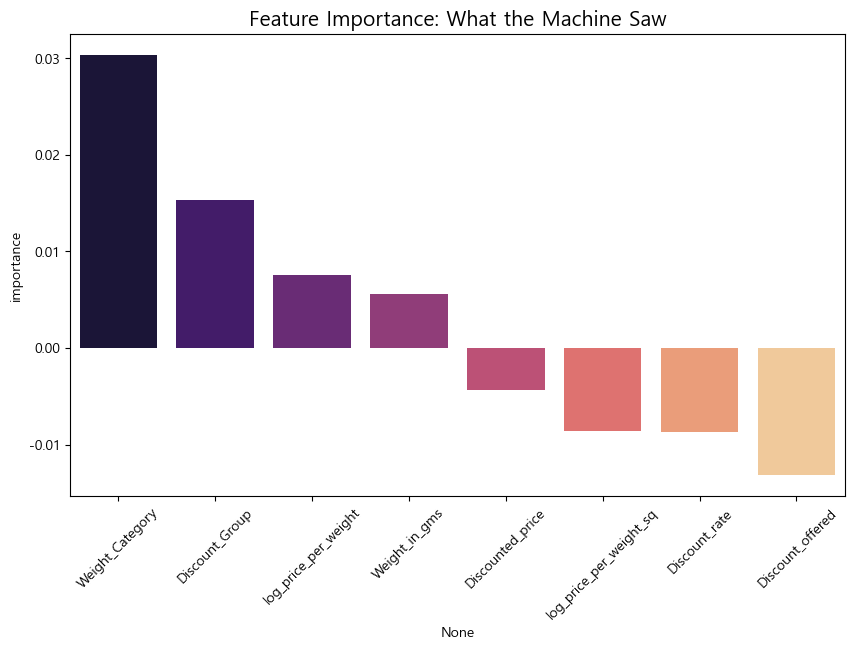

In [102]:
automl_paths = {
    "AutoML (Medium)": "AutogluonModels/ag-20260211_052042",
    "AutoML (Good)": "AutogluonModels/ag-20260211_052053",
    "AutoML (Best)": "AutogluonModels/ag-20260211_052410"}

test_data = test_df[selected_cols]
final_comparison = []

for name, path in automl_paths.items():
    predictor = TabularPredictor.load(path)
    perf = predictor.evaluate(test_data, silent=True)
    final_comparison.append({
        "Case": name,
        "Test_ROC_AUC": perf['roc_auc'],
        "Test_F1": perf['f1'],
        "Model_Type": "AutoML (Ensemble)"
    })

final_comparison.append({
    "Case": "Case B (Random)",
    "Test_ROC_AUC": 0.7508, #결과값
    "Test_F1": 0.6645,
    "Model_Type": "Manual (GradBoost)"
})

df_final = pd.DataFrame(final_comparison).sort_values("Test_ROC_AUC", ascending=False).reset_index(drop=True)
display(df_final.style.highlight_max(color='blue', subset=['Test_ROC_AUC']))

best_predictor = TabularPredictor.load(automl_paths["AutoML (Best)"])
fi = best_predictor.feature_importance(test_data)

display(fi.head(5).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(x=fi.index[:10], y=fi['importance'][:10], palette='magma')
plt.title('Feature Importance: What the Machine Saw', fontsize=15)
plt.xticks(rotation=45)
plt.show()

,Rank,Case,Type,Test_AUC,Train_AUC,Gap,F1,Acc,Overfit_Flag
0,1,Case B (Random),Manual,0.7508,0.7781,0.0273,0.6645,0.6777,False
1,2,AutoML (Medium),AutoML,0.7497,-,-,0.6500,-,-
2,3,Case B (Grid),Manual,0.7489,0.7824,0.0335,0.6575,0.6718,False
3,4,Case B (Before),Manual,0.7464,0.8186,0.0722,0.6609,0.6809,False
4,5,AutoML (Good),AutoML,0.7341,-,-,0.6946,-,-
5,6,AutoML (Best),AutoML,0.7318,-,-,0.6942,-,-
6,7,FE All (24),Manual,0.6172,1.0000,0.3828,0.6889,0.6305,True
7,8,Baseline,Manual,0.6162,1.0000,0.3838,0.6932,0.6318,True


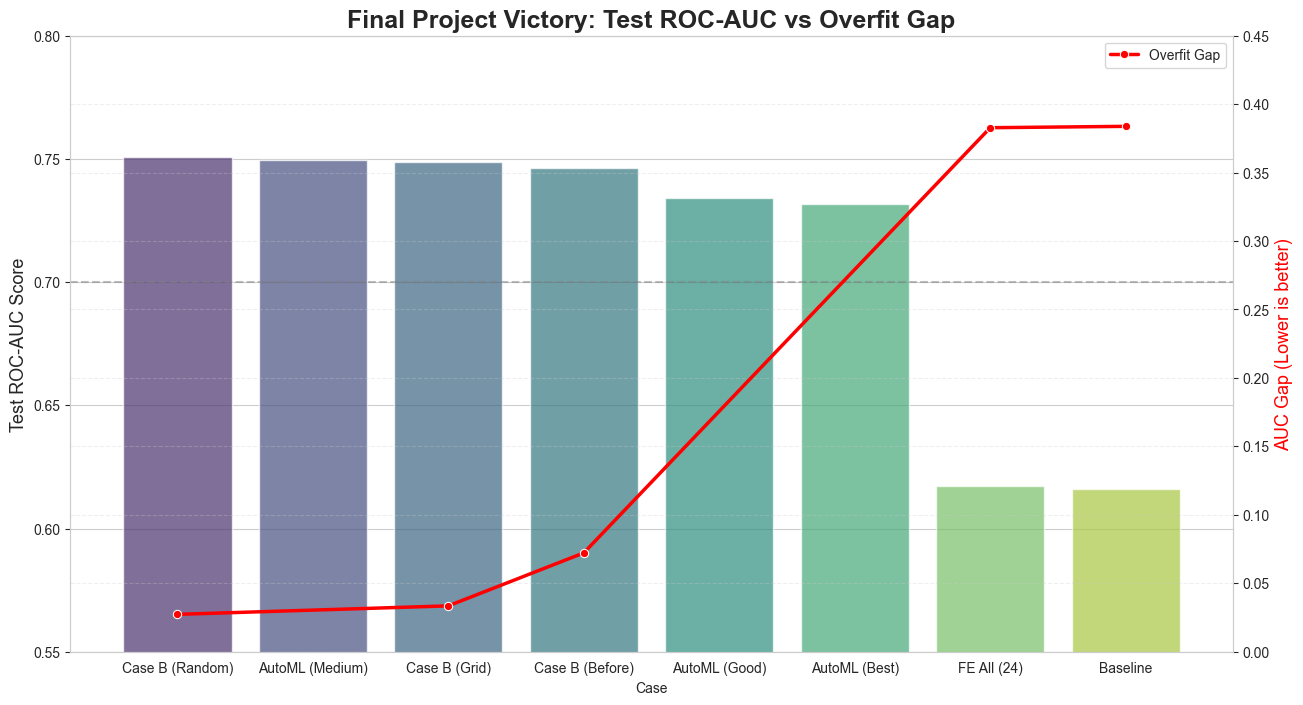

In [103]:
final_report_data = [
    {"Case": "Case B (Random)", "Type": "Manual", "Test_AUC": 0.7508, "Train_AUC": 0.7781, "Gap": 0.0273, "F1": 0.6645, "Acc": 0.6777},
    {"Case": "Case B (Grid)", "Type": "Manual", "Test_AUC": 0.7489, "Train_AUC": 0.7824, "Gap": 0.0335, "F1": 0.6575, "Acc": 0.6718},
    {"Case": "Case B (Before)", "Type": "Manual", "Test_AUC": 0.7464, "Train_AUC": 0.8186, "Gap": 0.0722, "F1": 0.6609, "Acc": 0.6809},
    {"Case": "FE All (24)", "Type": "Manual", "Test_AUC": 0.6172, "Train_AUC": 1.0000, "Gap": 0.3828, "F1": 0.6889, "Acc": 0.6305},
    {"Case": "Baseline", "Type": "Manual", "Test_AUC": 0.6162, "Train_AUC": 1.0000, "Gap": 0.3838, "F1": 0.6932, "Acc": 0.6318},
    
    {"Case": "AutoML (Medium)", "Type": "AutoML", "Test_AUC": 0.7497, "Train_AUC": np.nan, "Gap": np.nan, "F1": 0.6500, "Acc": np.nan},
    {"Case": "AutoML (Good)", "Type": "AutoML", "Test_AUC": 0.7341, "Train_AUC": np.nan, "Gap": np.nan, "F1": 0.6946, "Acc": np.nan},
    {"Case": "AutoML (Best)", "Type": "AutoML", "Test_AUC": 0.7318, "Train_AUC": np.nan, "Gap": np.nan, "F1": 0.6942, "Acc": np.nan}
]

df_report = pd.DataFrame(final_report_data)
df_report["Overfit_Flag"] = df_report["Gap"].apply(lambda x: "True" if x > 0.1 else ("-" if pd.isna(x) else "False"))
df_report = df_report.sort_values("Test_AUC", ascending=False).reset_index(drop=True)
df_report.insert(0, "Rank", range(1, len(df_report) + 1))

display(df_report.style
    .background_gradient(cmap='YlGnBu', subset=['Test_AUC', 'F1'])
    .highlight_max(color='lightgreen', subset=['Test_AUC'])
    .format({'Test_AUC': '{:.4f}', 'Train_AUC': '{:.4f}', 'Gap': '{:.4f}', 'F1': '{:.4f}', 'Acc': '{:.4f}'}, na_rep='-')
    .set_properties(**{'text-align': 'center'}))

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

ax1 = sns.barplot(x='Case', y='Test_AUC', data=df_report, palette='viridis', alpha=0.7)
plt.axhline(0.70, color='gray', linestyle='--', alpha=0.5) # 기준선
plt.ylim(0.55, 0.80)
plt.title('Final Project Victory: Test ROC-AUC vs Overfit Gap', fontsize=18, fontweight='bold')
plt.ylabel('Test ROC-AUC Score', fontsize=13)

ax2 = ax1.twinx()
sns.lineplot(x='Case', y='Gap', data=df_report, marker='o', color='red', linewidth=2.5, ax=ax2, label='Overfit Gap')
plt.ylim(0, 0.45)
plt.ylabel('AUC Gap (Lower is better)', color='red', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()